# Modelos de clasificación en Machine Learning con Python

**Mayo 2026 · Bloque III**

## Objetivos
- Entrenar clasificadores supervisados
- Evaluar accuracy, precision, recall, F1 y matriz de confusión
- Explicar la importancia de separar entrenamiento y prueba

## Preparación
Ejecuta la primera celda para cargar librerías. Si falta alguna librería, instálala desde el entorno con `pip install -r requirements.txt`.

## Carga y partición

In [2]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../datasets")
pd.set_option("display.max_columns", 50)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, RocCurveDisplay

df = pd.read_csv(DATA_DIR / "clientes_clasificacion.csv")
X = df.drop(columns=["abandono"])
y = df["abandono"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, stratify=y, random_state=42)
df.head()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,abandono
0,-1.411219,-0.514662,0.064036,0.586246,-0.458437,-0.322123,0
1,-1.075626,-0.401921,-0.018345,0.186611,1.047009,-0.195320,0
2,-2.084276,-1.661640,-2.440792,-2.384421,1.815373,-0.150552,0
3,-0.137564,-1.678457,-0.182502,0.021841,-0.748635,0.235910,0
4,-0.103918,-0.166164,-0.947579,-0.271781,-0.012278,-0.171772,0


## Modelo base: Logistic Regression

In [3]:
logit = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
logit.fit(X_train, y_train)
pred = logit.predict(X_test)
print(classification_report(y_test, pred, digits=3))

              precision    recall  f1-score   support

           0      0.739     0.829     0.782        41
           1      0.588     0.455     0.513        22

    accuracy                          0.698        63
   macro avg      0.664     0.642     0.647        63
weighted avg      0.686     0.698     0.688        63



## Random Forest y matriz de confusión

              precision    recall  f1-score   support

           0      0.932     1.000     0.965        41
           1      1.000     0.864     0.927        22

    accuracy                          0.952        63
   macro avg      0.966     0.932     0.946        63
weighted avg      0.956     0.952     0.951        63



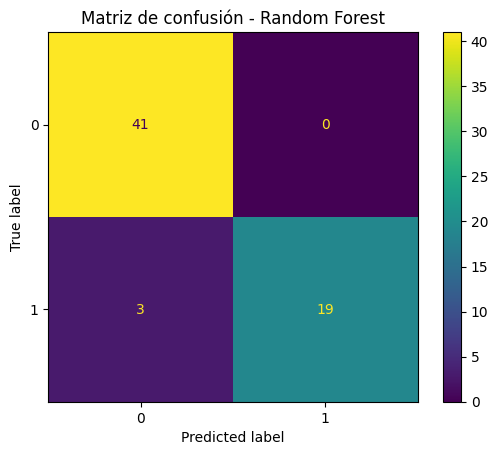

In [4]:
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print(classification_report(y_test, pred_rf, digits=3))

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Matriz de confusión - Random Forest")
plt.show()

## Curva ROC

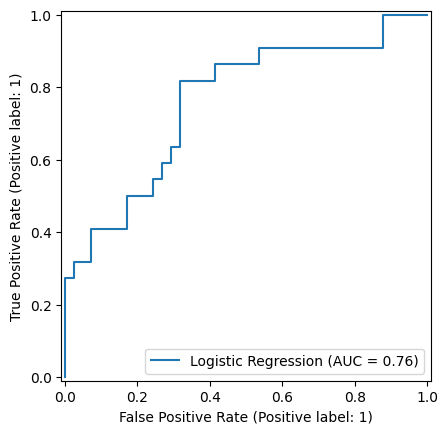

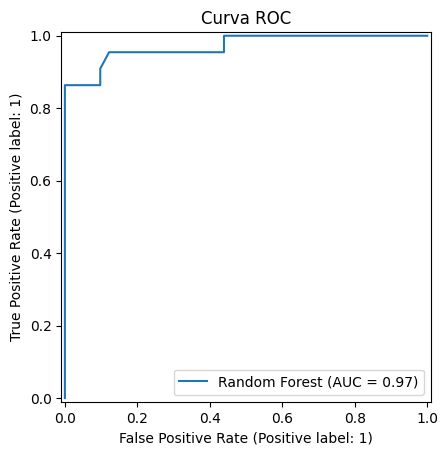

In [5]:
RocCurveDisplay.from_estimator(logit, X_test, y_test, name="Logistic Regression")
RocCurveDisplay.from_estimator(rf, X_test, y_test, name="Random Forest")
plt.title("Curva ROC")
plt.show()

## Actividad entregable
1. Modifica el dataset o hiperparámetros.
2. Añade una breve interpretación de resultados.
3. Guarda el notebook ejecutado y exporta una versión HTML/PDF si se solicita.